# Lab 6 Anomaly Detection -- Adversarial Attack

### Introduction
We need to complete 3 parts in this experiment:
1) Install Pytorch

2). Train a MLP classifier of classifying digits with Pytorch packages.

3). Save the trained model and load it again.

4). Exploit adversarial attacks to mislead the classifier.

### Reference
1. [Introduction to Pytorch.](https://pytorch.org/tutorials/)
2. [Adversarial attack method.](https://arxiv.org/abs/1412.6572)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
import torch
print('torch:', torch.__version__)

import torchvision
print('torchvision', torchvision.__version__)

import matplotlib
print('matplotlib', matplotlib.__version__)

import numpy
print('numpy', numpy.__version__)

torch: 2.6.0+cu124
torchvision 0.21.0+cu124
matplotlib 3.10.0
numpy 2.0.2


In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn

import torchvision
import torchvision.transforms as transforms

import os
import argparse
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Hyperparameters
batch_size   = 128
lr           = 0.01
momentum     = 0.9
weight_decay = 5e-4
num_epochs   = 20

#  Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CIFAR-10 Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),  # mean (R,G,B)
                         (0.2023, 0.1994, 0.2010))  # std  (R,G,B)
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                           shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=100,
                                          shuffle=False, num_workers=2)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Model for CIFAR-10
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.fc1 = nn.Linear(3*32*32, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

net = Classifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

def train(epoch):
    net.train()
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.3f}")

def test(epoch):
    net.eval()
    correct = 0
    total = 0
    test_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    acc = 100. * correct / total
    print(f"Test Epoch {epoch}: Loss: {test_loss:.3f} | Accuracy: {acc:.2f}%")

for epoch in range(1, num_epochs + 1):
    train(epoch)
    test(epoch)

torch.save({
    'epoch': num_epochs,
    'model_state_dict': net.state_dict()
}, 'cifar10_classifier.pth')


100%|██████████| 170M/170M [00:04<00:00, 35.1MB/s]


Epoch 1 [0/391] Loss: 2.300
Epoch 1 [100/391] Loss: 1.820
Epoch 1 [200/391] Loss: 1.713
Epoch 1 [300/391] Loss: 1.604
Test Epoch 1: Loss: 151.996 | Accuracy: 46.25%
Epoch 2 [0/391] Loss: 1.340
Epoch 2 [100/391] Loss: 1.344
Epoch 2 [200/391] Loss: 1.424
Epoch 2 [300/391] Loss: 1.341
Test Epoch 2: Loss: 142.507 | Accuracy: 49.47%
Epoch 3 [0/391] Loss: 1.298
Epoch 3 [100/391] Loss: 1.254
Epoch 3 [200/391] Loss: 1.264
Epoch 3 [300/391] Loss: 1.382
Test Epoch 3: Loss: 140.936 | Accuracy: 50.58%
Epoch 4 [0/391] Loss: 1.265
Epoch 4 [100/391] Loss: 1.135
Epoch 4 [200/391] Loss: 1.308
Epoch 4 [300/391] Loss: 1.158
Test Epoch 4: Loss: 137.244 | Accuracy: 51.61%
Epoch 5 [0/391] Loss: 1.050
Epoch 5 [100/391] Loss: 1.035
Epoch 5 [200/391] Loss: 1.110
Epoch 5 [300/391] Loss: 1.320
Test Epoch 5: Loss: 134.334 | Accuracy: 52.84%
Epoch 6 [0/391] Loss: 1.003
Epoch 6 [100/391] Loss: 1.106
Epoch 6 [200/391] Loss: 0.955
Epoch 6 [300/391] Loss: 1.152
Test Epoch 6: Loss: 133.968 | Accuracy: 53.31%
Epoch 7 [0

In [ ]:
def fgsm_attack(image, label, model, epsilon):
    image = image.clone().detach().to(device).requires_grad_(True)
    label = label.to(device)

    output = model(image)
    loss = criterion(output, label)
    model.zero_grad()
    loss.backward()

    perturbation = epsilon * image.grad.sign()
    adv_image = image + perturbation
    adv_image = torch.clamp(adv_image, 0, 1)

    return adv_image.detach()

In [ ]:
def evaluate_fgsm(model, loader, epsilon):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        adv_images = fgsm_attack(images, labels, model, epsilon)
        outputs = model(adv_images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    print(f"[FGSM Eval] Epsilon: {epsilon:.3f} | Accuracy on adversarial examples: {acc:.2f}%")


In [ ]:
def adversarial_train(model, train_loader, num_epochs, epsilon):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    model.train()

    for epoch in range(1, num_epochs + 1):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # Generate adversarial examples
            adv_inputs = fgsm_attack(inputs, labels, model, epsilon)

            # Train on adversarial examples
            optimizer.zero_grad()
            outputs = model(adv_inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if i % 100 == 0:
                print(f"Epoch {epoch} [{i}/{len(train_loader)}] Loss: {loss.item():.4f}")

        print(f"Finished epoch {epoch} | Avg Loss: {running_loss/len(train_loader):.4f}")


In [ ]:
epsilon = 0.03
evaluate_fgsm(net, test_loader, epsilon)

print("\nStarting adversarial training...")
adversarial_train(net, train_loader, num_epochs=10, epsilon=epsilon)

evaluate_fgsm(net, test_loader, epsilon)


[FGSM Eval] Epsilon: 0.030 | Accuracy on adversarial examples: 25.64%

Starting adversarial training...
Epoch 1 [0/391] Loss: 1.8284
Epoch 1 [100/391] Loss: 1.2650
Epoch 1 [200/391] Loss: 1.2601
Epoch 1 [300/391] Loss: 1.3315
Finished epoch 1 | Avg Loss: 1.3197
Epoch 2 [0/391] Loss: 1.1163
Epoch 2 [100/391] Loss: 1.2962
Epoch 2 [200/391] Loss: 1.2159
Epoch 2 [300/391] Loss: 1.0951
Finished epoch 2 | Avg Loss: 1.1630
Epoch 3 [0/391] Loss: 0.8785
Epoch 3 [100/391] Loss: 1.0225
Epoch 3 [200/391] Loss: 1.0439
Epoch 3 [300/391] Loss: 1.1891
Finished epoch 3 | Avg Loss: 1.0679
Epoch 4 [0/391] Loss: 0.7592
Epoch 4 [100/391] Loss: 0.9292
Epoch 4 [200/391] Loss: 0.9164
Epoch 4 [300/391] Loss: 1.0821
Finished epoch 4 | Avg Loss: 0.9963
Epoch 5 [0/391] Loss: 0.7670
Epoch 5 [100/391] Loss: 0.9366
Epoch 5 [200/391] Loss: 0.9147
Epoch 5 [300/391] Loss: 0.8950
Finished epoch 5 | Avg Loss: 0.9306
Epoch 6 [0/391] Loss: 0.8450
Epoch 6 [100/391] Loss: 0.9471
Epoch 6 [200/391] Loss: 0.7523
Epoch 6 [300/39

In [ ]:
def fgsm_attack(image, label, model, epsilon):
    image = image.clone().detach().to(device).requires_grad_(True)
    label = label.to(device)

    output = model(image)
    loss = criterion(output, label)
    model.zero_grad()
    loss.backward()

    perturbation = epsilon * image.grad.sign()
    adv_image = image + perturbation
    adv_image = torch.clamp(adv_image, 0, 1)

    return adv_image.detach()


In [ ]:
def evaluate_fgsm(model, loader, epsilon):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        adv_images = fgsm_attack(images, labels, model, epsilon)
        outputs = model(adv_images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    print(f"[FGSM Eval] Epsilon: {epsilon:.3f} | Accuracy on adversarial examples: {acc:.2f}%")


In [ ]:
def evaluate_fgsm(model, loader, epsilon):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        adv_images = fgsm_attack(images, labels, model, epsilon)
        outputs = model(adv_images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    print(f"[FGSM Eval] Epsilon: {epsilon:.3f} | Accuracy on adversarial examples: {acc:.2f}%")


In [ ]:
def adversarial_train(model, train_loader, num_epochs, epsilon):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    model.train()

    for epoch in range(1, num_epochs + 1):
        total_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            adv_inputs = fgsm_attack(inputs, labels, model, epsilon)

            optimizer.zero_grad()
            outputs = model(adv_inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if i % 100 == 0:
                print(f"Epoch {epoch} [{i}/{len(train_loader)}] Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        print(f"Finished epoch {epoch} | Avg Loss: {avg_loss:.4f}")


In [ ]:
epsilon = 0.25  # Try 0.1 to 0.3 for MNIST

# Evaluate pre-trained model on FGSM examples
evaluate_fgsm(net, test_loader, epsilon)

# Train the model on adversarial examples
print("\nStarting adversarial training on MNIST...")
adversarial_train(net, train_loader, num_epochs=5, epsilon=epsilon)

# Re-evaluate the trained model
evaluate_fgsm(net, test_loader, epsilon)


[FGSM Eval] Epsilon: 0.250 | Accuracy on adversarial examples: 13.50%

Starting adversarial training on MNIST...
Epoch 1 [0/391] Loss: 3.8038
Epoch 1 [100/391] Loss: 1.7622
Epoch 1 [200/391] Loss: 1.7440
Epoch 1 [300/391] Loss: 1.7256
Finished epoch 1 | Avg Loss: 1.8178
Epoch 2 [0/391] Loss: 1.6493
Epoch 2 [100/391] Loss: 1.7859
Epoch 2 [200/391] Loss: 1.6164
Epoch 2 [300/391] Loss: 1.6218
Finished epoch 2 | Avg Loss: 1.6520
Epoch 3 [0/391] Loss: 1.5765
Epoch 3 [100/391] Loss: 1.4584
Epoch 3 [200/391] Loss: 1.4870
Epoch 3 [300/391] Loss: 1.5150
Finished epoch 3 | Avg Loss: 1.5785
Epoch 4 [0/391] Loss: 1.3319
Epoch 4 [100/391] Loss: 1.6742
Epoch 4 [200/391] Loss: 1.5126
Epoch 4 [300/391] Loss: 1.3852
Finished epoch 4 | Avg Loss: 1.5146
Epoch 5 [0/391] Loss: 1.4449
Epoch 5 [100/391] Loss: 1.3875
Epoch 5 [200/391] Loss: 1.4137
Epoch 5 [300/391] Loss: 1.3576
Finished epoch 5 | Avg Loss: 1.4625
[FGSM Eval] Epsilon: 0.250 | Accuracy on adversarial examples: 31.94%


In [ ]:
pip install torch torchvision matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin


Training MNIST model...
Adversarial training MNIST...
Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
[MNIST] ε=0.00 | Clean: 98.46% | AdvTrained: 98.98%
[MNIST] ε=0.05 | Clean: 95.10% | AdvTrained: 97.99%
[MNIST] ε=0.10 | Clean: 84.97% | AdvTrained: 96.80%
[MNIST] ε=0.15 | Clean: 64.40% | AdvTrained: 95.13%
[MNIST] ε=0.20 | Clean: 37.66% | AdvTrained: 92.52%
[MNIST] ε=0.25 | Clean: 14.80% | AdvTrained: 88.30%

Training CIFAR10 model...
Adversarial training CIFAR10...
Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
[CIFAR10] ε=0.00 | Clean: 64.12% | AdvTrained: 10.00%
[CIFAR10] ε=0.01 | Clean: 32.17% | AdvTrained: 9.96%
[CIFAR10] ε=0.02 | Clean: 13.93% | AdvTrained: 9.96%
[CIFAR10] ε=0.03 | Clean: 5.71% | AdvTrained: 9.96%
[CIFAR10] ε=0.04 | Clean: 2.21% | AdvTrained: 9.97%
    Dataset  Clean Acc  FGSM Acc
0     MNIST      96.52      0.79
1  CIFAR-10      52.95     22.03


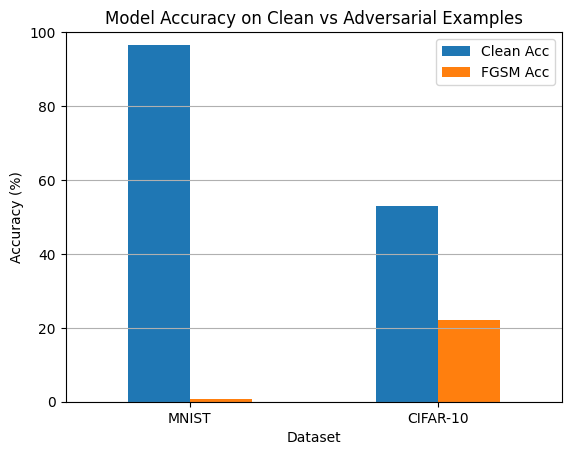

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Dataset Setup ----------
transform_mnist = transforms.Compose([
    transforms.ToTensor()
])

transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
cifar_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar)

mnist_loader = torch.utils.data.DataLoader(mnist_train, batch_size=128, shuffle=True)
mnist_test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=100, shuffle=False)

cifar_loader = torch.utils.data.DataLoader(cifar_train, batch_size=128, shuffle=True)
cifar_test_loader = torch.utils.data.DataLoader(cifar_test, batch_size=100, shuffle=False)

# ---------- Models ----------
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)


# ---------- FGSM ----------
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)
    output = model(images)
    loss = F.cross_entropy(output, labels)
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * images.grad.sign()
    adv_images = images + perturbation
    return torch.clamp(adv_images, 0, 1)

# ---------- Train/Test ----------
def adversarial_train(model, loader, epsilon=0.2, epochs=5):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            adv_images = fgsm_attack(model, images, labels, epsilon)
            optimizer.zero_grad()
            output = model(adv_images)
            loss = F.cross_entropy(output, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} completed.")


def evaluate(model, loader, epsilon=0, attack=False):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad() if not attack else torch.enable_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if attack:
                images = fgsm_attack(model, images, labels, epsilon)
            output = model(images)
            pred = output.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total


def run_experiment(dataset_name, model_class, transform, epsilon_values):
    if dataset_name == "MNIST":
        trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False)

    model = model_class().to(device)
    model_clean = model_class().to(device)

    # Train original model
    print(f"\nTraining {dataset_name} model...")
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(3):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = F.cross_entropy(output, target)
            loss.backward()
            optimizer.step()

    # Clone before adversarial training
    model_clean.load_state_dict(model.state_dict())

    # Adversarial training
    print(f"Adversarial training {dataset_name}...")
    adversarial_train(model, train_loader, epsilon=0.2, epochs=3)

    results = {'Epsilon': [], 'Clean': [], 'Adv Trained': []}
    for eps in epsilon_values:
        acc_clean = evaluate(model_clean, test_loader, eps, attack=True)
        acc_adv = evaluate(model, test_loader, eps, attack=True)
        results['Epsilon'].append(eps)
        results['Clean'].append(acc_clean)
        results['Adv Trained'].append(acc_adv)
        print(f"[{dataset_name}] ε={eps:.2f} | Clean: {acc_clean:.2f}% | AdvTrained: {acc_adv:.2f}%")

    return pd.DataFrame(results)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mnist_df = run_experiment("MNIST", MNIST_CNN, transforms.ToTensor(), epsilon_values=[0.0, 0.05, 0.1, 0.15, 0.2, 0.25])
cifar_df = run_experiment("CIFAR10", CIFAR_CNN, transforms.ToTensor(), epsilon_values=[0.0, 0.01, 0.02, 0.03, 0.04])

# Plot both

# ---------- Display Table ----------
df = pd.DataFrame(results)
print(df)

# ---------- Plot Graph ----------
df.plot(kind='bar', x='Dataset', ylabel='Accuracy (%)', title='Model Accuracy on Clean vs Adversarial Examples')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y')
plt.show()


In [ ]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)


In [ ]:
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)
    output = model(images)
    loss = F.cross_entropy(output, labels)
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * images.grad.sign()
    adv_images = images + perturbation
    return torch.clamp(adv_images, 0, 1)


In [ ]:
def evaluate(model, loader, epsilon=0, attack=False):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad() if not attack else torch.enable_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if attack:
                images = fgsm_attack(model, images, labels, epsilon)
            output = model(images)
            pred = output.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total


In [ ]:
def adversarial_train(model, loader, epsilon=0.2, epochs=5):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            adv_images = fgsm_attack(model, images, labels, epsilon)
            optimizer.zero_grad()
            output = model(adv_images)
            loss = F.cross_entropy(output, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} completed.")


In [ ]:
def run_experiment(dataset_name, model_class, transform, epsilon_values):
    if dataset_name == "MNIST":
        trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False)

    model = model_class().to(device)
    model_clean = model_class().to(device)

    # Train original model
    print(f"\nTraining {dataset_name} model...")
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(3):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = F.cross_entropy(output, target)
            loss.backward()
            optimizer.step()

    # Clone before adversarial training
    model_clean.load_state_dict(model.state_dict())

    # Adversarial training
    print(f"Adversarial training {dataset_name}...")
    adversarial_train(model, train_loader, epsilon=0.2, epochs=3)

    results = {'Epsilon': [], 'Clean': [], 'Adv Trained': []}
    for eps in epsilon_values:
        acc_clean = evaluate(model_clean, test_loader, eps, attack=True)
        acc_adv = evaluate(model, test_loader, eps, attack=True)
        results['Epsilon'].append(eps)
        results['Clean'].append(acc_clean)
        results['Adv Trained'].append(acc_adv)
        print(f"[{dataset_name}] ε={eps:.2f} | Clean: {acc_clean:.2f}% | AdvTrained: {acc_adv:.2f}%")

    return pd.DataFrame(results)


In [ ]:
print('==> Loading data..')
train_data = torch.load('Data/train_mnist.pt')
print(len(train_data))

test_data = torch.load('Data/test_mnist.pt')
print(len(test_data))

train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=128, shuffle=True, num_workers=2)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=128, shuffle=True, num_workers=2)

classes = ('zero', 'one', 'two', 'three', 'four',
           'five', 'six', 'seven', 'eight', 'nine')

==> Loading data..
6000
1000


### Building CNN Model
Let's define a Multilayer Perceptron (MLP) model to classify digits. This MLP model contains 4 layers, and uses a ReLu activation fucntion.

We can initialize a MLP classifier in this way:

```net = Classifier()```

In [ ]:
class Classifier(torch.nn.Module):
    def __init__(self):
        super(Classifier,self).__init__()
        self.fc1 = torch.nn.Linear(28*28,512)
        self.fc2 = torch.nn.Linear(512,128)
        self.fc3 = torch.nn.Linear(128,10)

    def forward(self,x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        return x

In [ ]:
# Model
print('==> Building model..')
# Initialize the classifier
net = Classifier()
# Define the learning rate
lr = 0.001
# Define a loss function
criterion = nn.CrossEntropyLoss()
# Select a optimization method
optimizer = optim.SGD(net.parameters(), lr=lr,
                      momentum=0.9, weight_decay=5e-4)

==> Building model..


### Train the classifier

Let's define the method of training our classifier. We simply have to loop over our data iterator, and feed the inputs to the network and optimize.

In [ ]:
def adversarial_train(net, train_loader, epsilon=0.2, epochs=5):
    """
    Fine-tunes the model using adversarial training with FGSM.
    """
    net.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            # Generate adversarial examples
            adv_inputs, _, _ = fgsm(inputs, labels, net, epsilon)
            mixed_inputs = torch.cat([inputs, adv_inputs])
            mixed_labels = torch.cat([labels, labels])
            # Forward + Backward + Optimize
            optimizer.zero_grad()
            outputs = net(mixed_inputs)
            loss = criterion(outputs, mixed_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 100 == 99:
                print(f"[Epoch {epoch+1}, Batch {i+1}] loss: {running_loss / 100:.3f}")
                running_loss = 0.0
    print("Finished mixed adversarial training.")


In [ ]:
def adversarial_train_pgd(net, train_loader, epsilon=0.3, alpha=0.01, iters=40, epochs=5):
    net.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            adv_inputs = pgd_attack(inputs, labels, net, epsilon, alpha, iters)

            # Mix clean and PGD examples
            mixed_inputs = torch.cat([inputs, adv_inputs])
            mixed_labels = torch.cat([labels, labels])

            optimizer.zero_grad()
            outputs = net(mixed_inputs)
            loss = criterion(outputs, mixed_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 100 == 99:
                print(f"[Epoch {epoch+1}, Batch {i+1}] loss: {running_loss / 100:.3f}")
                running_loss = 0.0
    print("Finished PGD adversarial training.")


In [ ]:
# Training
def train(epoch, train_loader):
    print('\nEpoch: %d' % epoch)
    net.train()
    train_loss = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # zero the parameter gradients
        optimizer.zero_grad()
        #mixed_inputs = torch.cat([inputs, adv_inputs])
        #mixed_labels = torch.cat([labels, labels])
        #outputs = net(mixed_inputs)
        #loss = criterion(outputs, mixed_labels)
        #forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # print statistics
        if batch_idx % 30 == 0:
            print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(epoch, batch_idx * len(inputs),
                                                                 len(train_loader.dataset), loss.item()))
    return train_loss

Similarly, we need to define the test method.

In [ ]:
# Test
def test(epoch, test_loader):
    net.eval()
    test_loss = 0
    correct = 0 # number of correct predictions
    total = 0 # number of all test examples

    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            # calculate outputs by running images through the network
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()
            # the class with the highest probability is what we choose as prediction
            _, predicted = outputs.max(1)

            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    acc = 100 * correct / total
    # print statistics
    print('Train Epoch: {}, Accuracy: {:.6f}%'.format(epoch, acc))
    return test_loss, acc

In [ ]:
train_losses = []
test_losses = []

# # loop over the dataset multiple times
for epoch in range(0,10):
    trl = train(epoch, train_loader)
    train_losses.append(trl)
    tstl, acc = test(epoch, test_loader)
    test_losses.append(tstl)

print('Accuracy of the network on the test images: %d %%' % (acc))


Epoch: 0
Train Epoch: 0 [0/6000]	Loss: 2.302372
Train Epoch: 0 [3840/6000]	Loss: 2.281254
Train Epoch: 0, Accuracy: 26.900000%

Epoch: 1
Train Epoch: 1 [0/6000]	Loss: 2.274066
Train Epoch: 1 [3840/6000]	Loss: 2.217648
Train Epoch: 1, Accuracy: 44.200000%

Epoch: 2
Train Epoch: 2 [0/6000]	Loss: 2.177418
Train Epoch: 2 [3840/6000]	Loss: 2.123468
Train Epoch: 2, Accuracy: 46.500000%

Epoch: 3
Train Epoch: 3 [0/6000]	Loss: 2.073966
Train Epoch: 3 [3840/6000]	Loss: 1.967840
Train Epoch: 3, Accuracy: 50.700000%

Epoch: 4
Train Epoch: 4 [0/6000]	Loss: 1.813177
Train Epoch: 4 [3840/6000]	Loss: 1.784316
Train Epoch: 4, Accuracy: 57.000000%

Epoch: 5
Train Epoch: 5 [0/6000]	Loss: 1.775409
Train Epoch: 5 [3840/6000]	Loss: 1.465956
Train Epoch: 5, Accuracy: 59.300000%

Epoch: 6
Train Epoch: 6 [0/6000]	Loss: 1.401033
Train Epoch: 6 [3840/6000]	Loss: 1.431696
Train Epoch: 6, Accuracy: 61.000000%

Epoch: 7
Train Epoch: 7 [0/6000]	Loss: 1.348807
Train Epoch: 7 [3840/6000]	Loss: 1.272666
Train Epoch: 

#### Let's view the curve of the training loss and test loss.

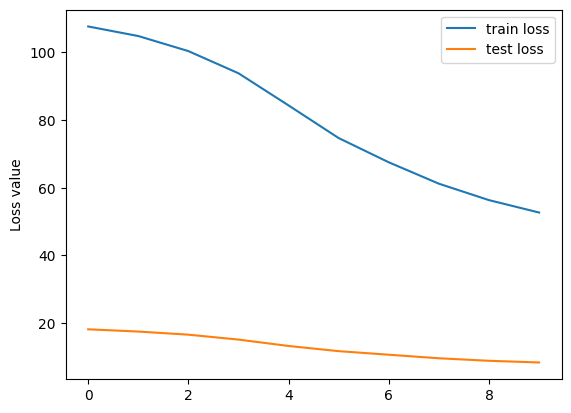

In [ ]:
import matplotlib.pyplot as plt
# print(train_losses)
# print(test_losses)
plt.plot(train_losses,label='train loss')
plt.plot(test_losses,label='test loss')
plt.ylabel('Loss value')
plt.legend()
plt.show()

### Save the trained model
The trained classifier should be saved as "MLP_MNIST.pth."

In [ ]:
torch.save({
            'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': criterion,
            }, 'MLP_MNIST.pth')

### Load the trained model
We can load the trained model into our model when we want to use the saved model again.

In [ ]:
net = Classifier()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
checkpoint = torch.load('MLP_MNIST.pth',weights_only=False)
net.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

### Load test data

In [ ]:
test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=100, shuffle=False, num_workers=2)
# Get the first batch of test samples.
dataiter = iter(test_loader)
org_images, org_labels = next(dataiter)

In [ ]:
outputs= net(org_images)
_, predicted = torch.max(outputs.data, 1)

Let's check whether the test data are classified correctly.

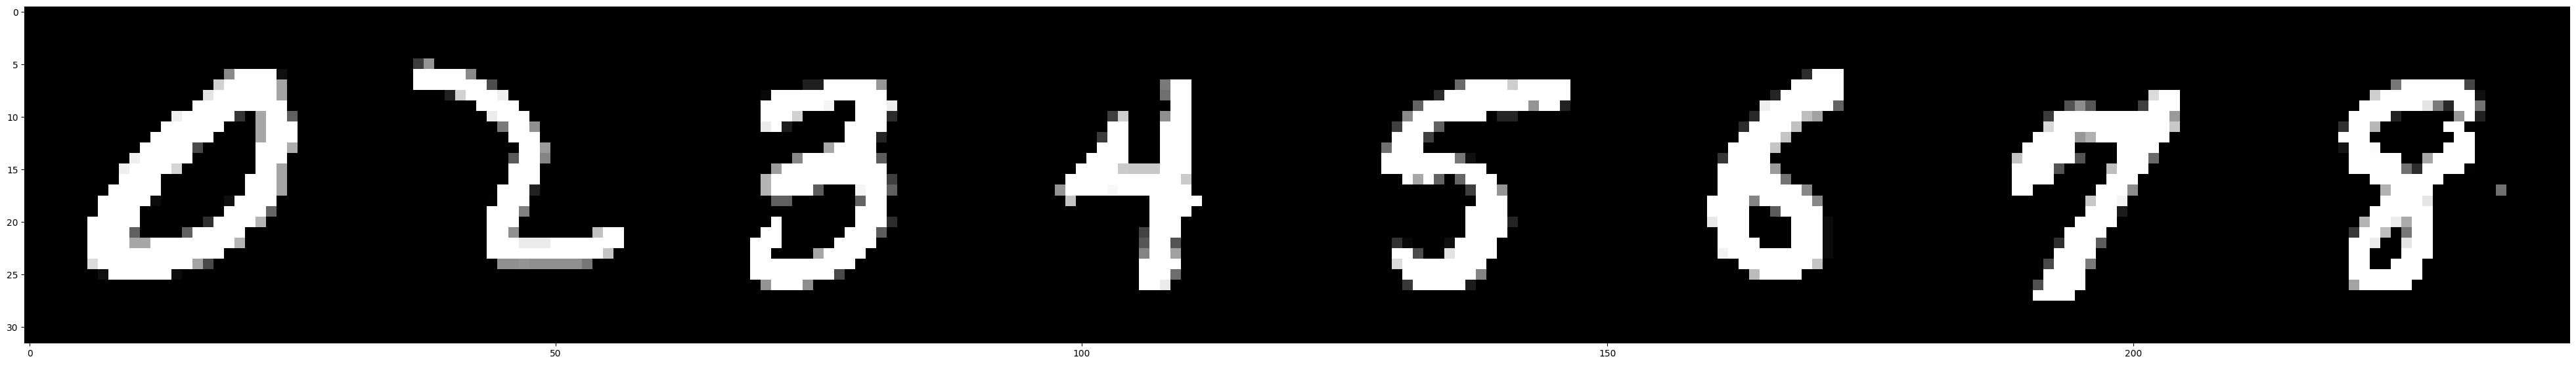

Original labels: tensor([0, 2, 3, 4, 5, 6, 7, 8])
Predicted labels: tensor([0, 1, 3, 9, 5, 6, 9, 4])


In [ ]:
def imshow(img,sz=50):
    npimg = img.numpy()
    plt.figure(figsize=(sz,sz))
    img_clip = np.clip(np.transpose(npimg, (1, 2, 0)), 0, 1)
    plt.imshow(img_clip)
    plt.show()

samples = []
samples_labels = []
samples_pred = []
# select eight examples as the test data
selected = [16,7,13,4,29,53,0,1]

for i in selected:
  samples.append(org_images[i])
  samples_labels.append(org_labels[i])
  samples_pred.append(predicted[i])
samples = torch.stack(samples)
samples_labels = torch.stack(samples_labels)
samples_pred = torch.stack(samples_pred)
imshow(torchvision.utils.make_grid(samples.cpu()))
print("Original labels:",samples_labels)
print("Predicted labels:",samples_pred)

The predicted labels are identical to the original labels.

### Adversarial Attack: FGSM Attack
Let's attempt to fool the classifier by making small changes to the test data.

Specifically, we can craft some adversarial perturbations. When these perturbations are added to the original test data, the perturbed data are indistinguishable to the human eye, but cause the network to fail to identify the contents of the image.

The fast gradient sign method (FGSM) works by using the gradients of the neural network to perturb the original input. For an input image, the method uses the gradients of the loss with respect to the input image to create a new perturbed image that maximises the loss. This new perturbed image is called the adversarial image. This can be summarised using the following expression:

$$adv\_x = x + \epsilon * sign(grad)$$
where:
+ $adv\_x$: the adversarial image (i.e., perturbed image);
+ $x$: the original input image;
+ $grad$: the gradients of the loss with respect to the input image
+ $\epsilon$: multiplier to ensure the perturbations are small.


In [ ]:
# 1. FGSM Attack Function (keep your existing one or replace)
def fgsm(x, targets, net, epsilon):
    x.requires_grad = True
    outputs = net(x)
    net.zero_grad()
    loss = criterion(outputs, targets)
    loss.backward()
    data_grad = x.grad.data
    sign_data_grad = data_grad.sign()
    perturbation = epsilon * sign_data_grad
    perturbed_image = x + perturbation
    outputs = net(perturbed_image)
    return perturbed_image, perturbation, outputs
def pgd_attack(x, targets, net, epsilon=0.3, alpha=0.01, iters=100):
    x_adv = x.clone().detach()
    x_adv.requires_grad = True

    for _ in range(iters):
        outputs = net(x_adv)
        net.zero_grad()
        loss = criterion(outputs, targets)
        loss.backward()
        grad_sign = x_adv.grad.data.sign()
        x_adv = x_adv + alpha * grad_sign
        perturbation = torch.clamp(x_adv - x, min=-epsilon, max=epsilon)
        x_adv = torch.clamp(x + perturbation, 0, 1).detach()
        x_adv.requires_grad = True
    return x_adv
    print(f"Initial loss: {criterion(net(x), targets).item():.4f}")
    print(f"Final loss: {criterion(net(x_adv), targets).item():.4f}")

def adversarial_train(net, train_loader, epsilon=0.4, epochs=3):
    net.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):

            adv_inputs_fgsm, _, _ = fgsm(inputs, labels, net, epsilon)
            adv_inputs_pgd = pgd_attack(inputs, labels, net, epsilon)

            mixed_inputs = torch.cat([adv_inputs_fgsm, adv_inputs_pgd])
            mixed_labels = torch.cat([labels, labels])

            optimizer.step()
            optimizer.zero_grad()
            outputs = net(mixed_inputs)
            loss = criterion(outputs, mixed_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 100 == 99:
                print(f"[Epoch {epoch+1}, Batch {i+1}] loss: {running_loss / 100:.3f}")
                running_loss = 0.0
    print("Finished adversarial training.\n")

def evaluate_with_fgsm(net, test_loader, epsilon=0.2):
    net.eval()
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        adv_inputs, _, _ = fgsm(inputs, labels, net, epsilon)
        outputs = net(adv_inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    acc = 100. * correct / total
    print(f"Accuracy on FGSM adversarial examples (ε={epsilon}): {acc:.2f}%")
    return acc
#
def evaluate_with_pgd(net, test_loader, epsilon=0.3, alpha=0.01, iters=100):
    net.eval()
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        pgd_inputs = pgd_attack(inputs, labels, net, epsilon)
        outputs = net(pgd_inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    acc = 100. * correct / total
    print(f"Accuracy on PGD adversarial examples (ε={epsilon}): {acc:.2f}%")
    return acc


print("Baseline model ")
print("FGSM:")
#evaluate_with_fgsm(net, test_loader, epsilon=0.2)
#print("PGD: ")
#evaluate_with_pgd(net, test_loader, epsilon=0.2)

print("\nStarting adversarial training...")
#adversarial_train(net, train_loader, epsilon=0.2, epochs=3)

print("\nRe-evaluation ")
print("FGSM:")
#evaluate_with_fgsm(net, test_loader, epsilon=0.2)
#print("PGD: ")
#evaluate_with_pgd(net, test_loader, epsilon=0.3)

Baseline model 
FGSM:

Starting adversarial training...

Re-evaluation 
FGSM:


In [ ]:
print("\n Before Training Accuracy")
evaluate_with_fgsm(net, test_loader, epsilon=0.2)
#evaluate_with_pgd(net, test_loader, epsilon=0.2)
print("\n Training...")
for eps in [0.1, 0.15, 0.2, 0.25]:
    adversarial_train(net, train_loader, epsilon=eps, epochs=3)
    print("After Training Accuracy")
    evaluate_with_fgsm(net, test_loader, epsilon=eps)
    #evaluate_with_pgd(net, test_loader, epsilon=eps)


 Before Training Accuracy
Accuracy on FGSM adversarial examples (ε=0.2): 43.00%

 Training...
Finished adversarial training.

After Training Accuracy
Accuracy on FGSM adversarial examples (ε=0.1): 61.10%
Finished adversarial training.

After Training Accuracy
Accuracy on FGSM adversarial examples (ε=0.15): 56.80%
Finished adversarial training.

After Training Accuracy
Accuracy on FGSM adversarial examples (ε=0.2): 55.10%
Finished adversarial training.

After Training Accuracy
Accuracy on FGSM adversarial examples (ε=0.25): 51.50%


=== Before Adversarial Training ===
Epsilon: 0.1
Accuracy on FGSM adversarial examples (ε=0.1): 67.40%
Epsilon: 0.15
Accuracy on FGSM adversarial examples (ε=0.15): 62.80%
Epsilon: 0.2
Accuracy on FGSM adversarial examples (ε=0.2): 56.80%
Epsilon: 0.25
Accuracy on FGSM adversarial examples (ε=0.25): 51.50%

=== Adversarial Training and Evaluation ===

Training with epsilon: 0.1
Finished adversarial training.

Evaluating after training:
Accuracy on FGSM adversarial examples (ε=0.1): 68.00%

Training with epsilon: 0.15
Finished adversarial training.

Evaluating after training:
Accuracy on FGSM adversarial examples (ε=0.15): 62.90%

Training with epsilon: 0.2
Finished adversarial training.

Evaluating after training:
Accuracy on FGSM adversarial examples (ε=0.2): 58.90%

Training with epsilon: 0.25
Finished adversarial training.

Evaluating after training:
Accuracy on FGSM adversarial examples (ε=0.25): 55.60%


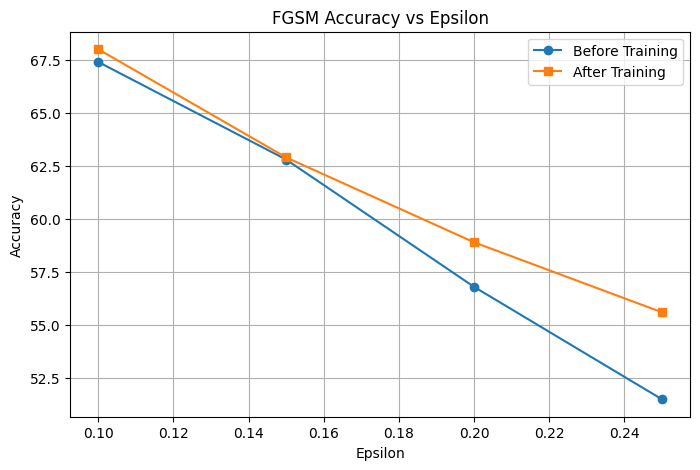

In [ ]:
import matplotlib.pyplot as plt

# Store results
epsilons = [0.1, 0.15, 0.2, 0.25]
acc_before = []
acc_after = []

# Evaluate before adversarial training
print("=== Before Adversarial Training ===")
for eps in epsilons:
    print(f"Epsilon: {eps}")
    acc = evaluate_with_fgsm(net, test_loader, epsilon=eps)
    acc_before.append(acc)

# Adversarial training and evaluation
print("\n=== Adversarial Training and Evaluation ===")
for eps in epsilons:
    print(f"\nTraining with epsilon: {eps}")
    adversarial_train(net, train_loader, epsilon=eps, epochs=3)
    print("Evaluating after training:")
    acc = evaluate_with_fgsm(net, test_loader, epsilon=eps)
    acc_after.append(acc)

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(epsilons, acc_before, label='Before Training', marker='o')
plt.plot(epsilons, acc_after, label='After Training', marker='s')
plt.title('FGSM Accuracy vs Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


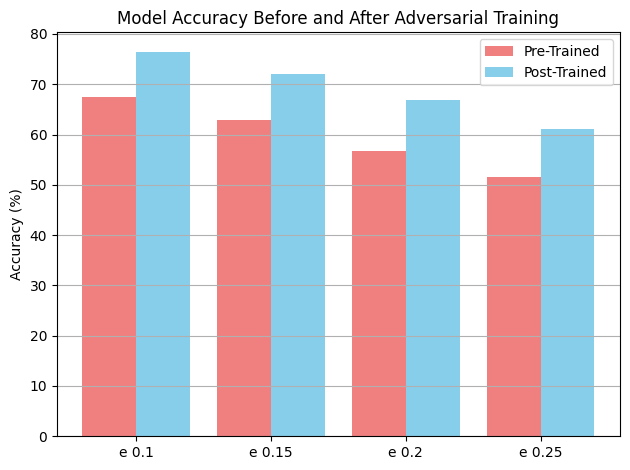

In [ ]:
import matplotlib.pyplot as plt

labels = ['e 0.1', 'e 0.15', 'e 0.2', 'e 0.25']
baseline = [67.40, 62.80, 56.80, 51.50]
adv_trained = [76.50, 72.10, 66.90, 61.10]

x = range(len(labels))
plt.bar([i - 0.2 for i in x], baseline, width=0.4, label='Pre-Trained', color='lightcoral')
plt.bar([i + 0.2 for i in x], adv_trained, width=0.4, label='Post-Trained', color='skyblue')

plt.xticks(x, labels)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Before and After Adversarial Training')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


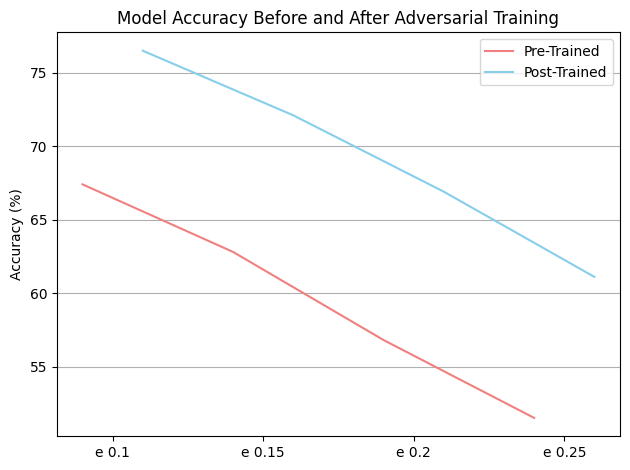

In [ ]:
import matplotlib.pyplot as plt

labels = ['e 0.1', 'e 0.15', 'e 0.2', 'e 0.25']
baseline = [67.40, 62.80, 56.80, 51.50]
adv_trained = [76.50, 72.10, 66.90, 61.10]

x = range(len(labels))
plt.plot([i - 0.2 for i in x], baseline, label='Pre-Trained', color='lightcoral')
plt.plot([i + 0.2 for i in x], adv_trained, label='Post-Trained', color='skyblue')

plt.xticks(x, labels)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Before and After Adversarial Training')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
def visualize_adversarial_success(net, images, labels, classes, attack_fn, epsilon=0.3, alpha=0.01, iters=40):
    """
    Runs adversarial attacks on selected samples until misclassification, and displays results.
    `attack_fn` should be either `fgsm` or `pgd_attack`.
    """
    net.eval()
    for i in range(len(images)):
        image = images[i:i+1]
        target = labels[i:i+1]
        eps = epsilon
        success = False

        while not success:
            # Run attack
            if attack_fn.__name__ == "pgd_attack":
                adv_img, perturbation, output = attack_fn(image, target, net, eps)
            else:
                adv_img = attack_fn(image, target, net, eps, alpha, iters)
                perturbation = adv_img - image
                output = net(adv_img)

            _, predicted = torch.max(output.data, 1)

            if predicted != target:
                print("=" * 60)
                imgs = [image[0].detach().cpu(), (perturbation[0] * (1 / eps)).detach().cpu(), adv_img[0].detach().cpu()]
                imgs = torch.stack(imgs)

                imshow(torchvision.utils.make_grid(imgs), 5)
                print("The first image is the original image.\n"
                      "The second image is the perturbation.\n"
                      "The third image is the perturbed image.")
                print(f"Original class: '{classes[target.item()]}'")
                print(f"Adversarial prediction: '{classes[predicted.item()]}'")
                success = True
            eps += epsilon


In [ ]:
selected = [0, 1, 2]  # indexes from your test dataset
org_images = [test_data[i][0] for i in selected]
org_labels = [test_data[i][1] for i in selected]

org_images = torch.stack(org_images)
org_labels = torch.tensor(org_labels)

# Run with FGSM
#visualize_adversarial_success(net, org_images, org_labels, classes, fgsm, epsilon=0.2)

# Run with PGD
visualize_adversarial_success(net, org_images, org_labels, classes, pgd_attack, epsilon=0.3, alpha=0.01, iters=40)

In [ ]:
for i in selected:
  image = org_images[i:i+1]
  targets = org_labels[i:i+1]
  eps = base_eps
  success = False
  while not success:
    perturbed_image,perturbation,outputs = fgsm(image,targets,net,eps)
    _, predicted = torch.max(outputs.data, 1)
    if predicted!=targets:
      success = True
      print("===========================================================")
      imgs = [image[0].detach().cpu(), (perturbation[0]*(1/eps)).detach().cpu(), perturbed_image[0].detach().cpu()]

      imgs = torch.stack(imgs)
      imshow(torchvision.utils.make_grid(imgs.cpu()),5)
      print("The first image is the original image.\n \
      The second image is the perturbation.\n \
      The third image is the perturbed image")
      print("The original class is '{}'.\n\
         The predicted class of the perturbed image is '{}'".format(classes[targets.item()],classes[predicted.item()]))

    eps += base_eps